# Phase 4: Anomaly and Outlier Detection

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from scipy import stats

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── Task 1: Statistical Methods (IQR & Z-Score) ──────────────────────────────
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

df_stat = raw_data[num_cols].copy()

# --- IQR ---
Q1  = df_stat.quantile(0.25)
Q3  = df_stat.quantile(0.75)
IQR = Q3 - Q1

iqr_mask    = ((df_stat < (Q1 - 1.5 * IQR)) | (df_stat > (Q3 + 1.5 * IQR)))
iqr_outlier = iqr_mask.any(axis=1)

iqr_summary = pd.DataFrame({
    'Q1'          : Q1,
    'Q3'          : Q3,
    'IQR'         : IQR,
    'Lower Bound' : Q1 - 1.5 * IQR,
    'Upper Bound' : Q3 + 1.5 * IQR,
    'Outlier Count': iqr_mask.sum()
})

print("=== IQR Outlier Summary ===")
print(iqr_summary.to_string())
print(f"\nTotal baris dengan outlier IQR (min 1 kolom): {iqr_outlier.sum():,} ({iqr_outlier.mean()*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== IQR Outlier Summary ===
             Q1      Q3     IQR  Lower Bound  Upper Bound  Outlier Count
age        33.0    48.0    15.0         10.5         70.5            487
balance    72.0  1428.0  1356.0      -1962.0       3462.0           4729
duration  103.0   319.0   216.0       -221.0        643.0           3235
campaign    1.0     3.0     2.0         -2.0          6.0           3064
pdays      -1.0    -1.0     0.0         -1.0         -1.0           8257
previous    0.0     0.0     0.0          0.0          0.0           8257

Total baris dengan outlier IQR (min 1 kolom): 17,018 (37.64%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Metode IQR mendeteksi 17.018 observasi (37,64%) sebagai outlier pada setidaknya satu variabel numerik. Sebagian besar outlier berasal dari variabel pdays dan previous yang kemungkinan merupakan nilai khusus (valid secara bisnis), sedangkan outlier pada balance, duration, dan campaign mengindikasikan perilaku nasabah yang ekstrem namun realistis sehingga lebih tepat dipertahankan untuk analisis lanjutan daripada langsung dihapus.

In [ ]:
# --- Z-Score ---
z_scores    = np.abs(stats.zscore(df_stat))
z_mask      = z_scores > 3
z_outlier   = z_mask.any(axis=1)

zscore_summary = pd.DataFrame({
    'Mean'         : df_stat.mean().round(2),
    'Std'          : df_stat.std().round(2),
    'Outlier Count': z_mask.sum()
}, index=num_cols)

print("=== Z-Score Outlier Summary (threshold |z| > 3) ===")
print(zscore_summary.to_string())
print(f"\nTotal baris dengan outlier Z-Score (min 1 kolom): {z_outlier.sum():,} ({z_outlier.mean()*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== Z-Score Outlier Summary (threshold |z| > 3) ===
             Mean      Std  Outlier Count
age         40.94    10.62           5234
balance   1362.27  3044.77           5234
duration   258.16   257.53           5234
campaign     2.76     3.10           5234
pdays       40.20   100.13           5234
previous     0.58     2.30           5234

Total baris dengan outlier Z-Score (min 1 kolom): 5,002 (11.06%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Metode Z-Score mengidentifikasi 5.002 observasi (11,06%) sebagai outlier pada minimal satu variabel numerik. Outlier yang terdeteksi cenderung merupakan nilai yang sangat ekstrem namun masih mungkin valid secara bisnis, sehingga lebih tepat dipertahankan untuk analisis lanjutan daripada langsung dihapus.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

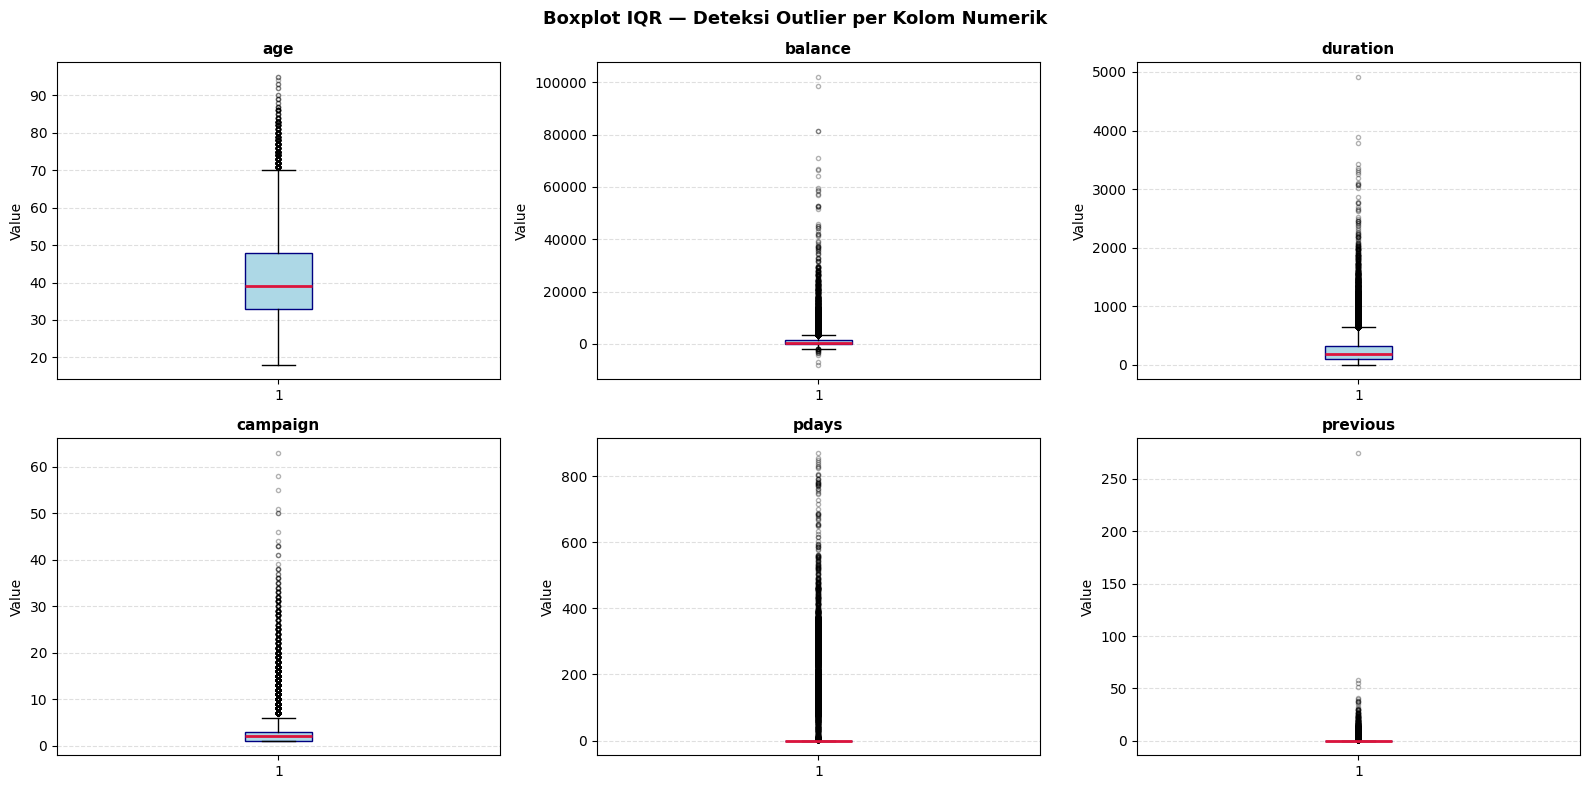

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# --- Visualisasi: Boxplot IQR ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_stat[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='crimson', linewidth=2),
                    flierprops=dict(marker='o', color='crimson', alpha=0.3, markersize=3))
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Boxplot IQR — Deteksi Outlier per Kolom Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Visualisasi boxplot memperlihatkan adanya outlier pada seluruh variabel numerik, dengan jumlah yang paling menonjol pada balance, duration, pdays, dan previous. Pola ini menunjukkan distribusi data yang tidak simetris dan mengandung nilai ekstrem yang masih berpotensi valid secara bisnis.

In [ ]:
X_selected = X_corr[selected_features]

print(X_selected.shape)
print(selected_features)

(45211, 15)
['duration_bin_very_long', 'poutcome_success', 'pdays', 'month', 'contact_unknown', 'housing', 'previous', 'duration_bin_medium', 'marital_married', 'education', 'day', 'marital_single', 'campaign', 'balance_bin_very_high', 'job_management']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Pada tahap Anomaly and Outlier Detection, digunakan 15 fitur hasil feature selection pada Phase 1 sebagai input untuk model Isolation Forest. Penggunaan fitur yang telah diseleksi bertujuan memastikan proses deteksi anomali berfokus pada variabel yang paling informatif, sehingga dapat meningkatkan efektivitas model dalam mengidentifikasi observasi yang menyimpang dari pola data normal.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Isolation Forest — Anomali terdeteksi : 2,261 (5.00%)
Data normal                            : 42,950


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

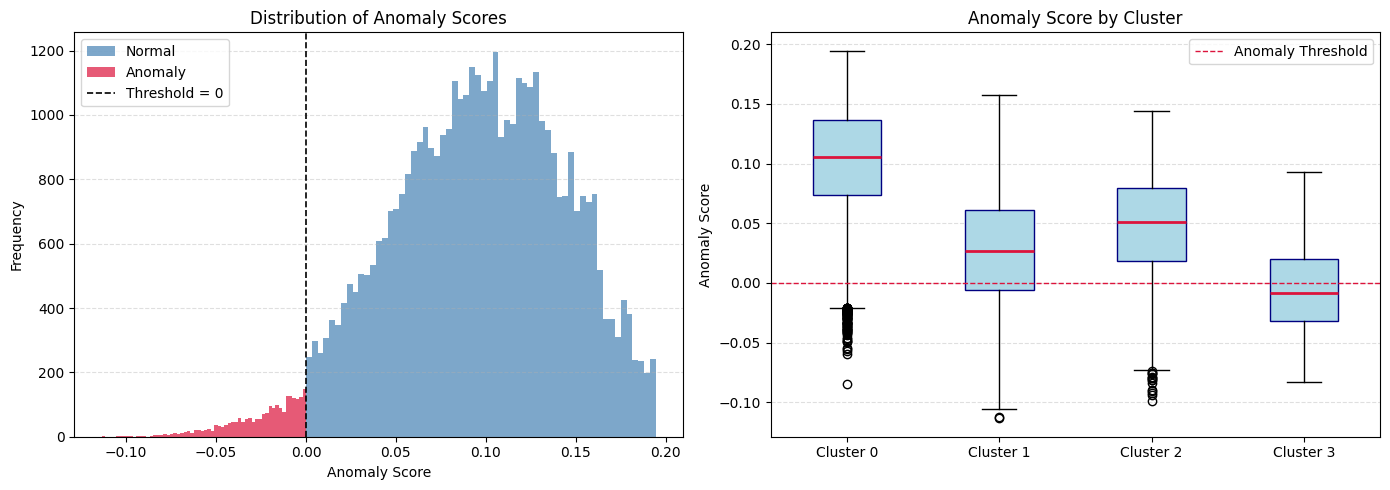

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# Isolation Forest
# =====================================================

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso_labels = iso_forest.fit_predict(X_selected)
iso_scores = iso_forest.decision_function(X_selected)

# Simpan hasil
raw_data['iso_label'] = iso_labels
raw_data['iso_score'] = iso_scores

# Ringkasan
n_anomalies = (iso_labels == -1).sum()

print(f"Isolation Forest — Anomali terdeteksi : {n_anomalies:,} ({n_anomalies/len(iso_labels)*100:.2f}%)")
print(f"Data normal                            : {(iso_labels == 1).sum():,}")

# =====================================================
# Visualisasi
# =====================================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram
axes[0].hist(
    iso_scores[iso_labels == 1],
    bins=60,
    alpha=0.7,
    color='steelblue',
    label='Normal'
)

axes[0].hist(
    iso_scores[iso_labels == -1],
    bins=60,
    alpha=0.7,
    color='crimson',
    label='Anomaly'
)

axes[0].axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Threshold = 0'
)

axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Anomaly Scores")
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# =====================================================
# Boxplot berdasarkan cluster dari Phase 2
# =====================================================

cluster_ids = sorted(raw_data['cluster'].unique())

bp_data = [
    raw_data.loc[raw_data['cluster'] == k, 'iso_score']
    for k in cluster_ids
]

axes[1].boxplot(
    bp_data,
    labels=[f'Cluster {k}' for k in cluster_ids],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='crimson', linewidth=2)
)

axes[1].axhline(
    0,
    color='crimson',
    linestyle='--',
    linewidth=1,
    label='Anomaly Threshold'
)

axes[1].set_ylabel("Anomaly Score")
axes[1].set_title("Anomaly Score by Cluster")
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Isolation Forest mendeteksi 2.261 observasi (5,00%) sebagai anomali dan 42.950 observasi (95,00%) sebagai data normal. Mayoritas data memiliki anomaly score positif sehingga mengikuti pola umum, sedangkan observasi dengan skor negatif dikategorikan sebagai anomali. Berdasarkan distribusi per cluster, Cluster 3 menunjukkan kecenderungan paling dekat dengan kategori anomali. Secara bisnis, anomali yang terdeteksi lebih merepresentasikan unusual but valid cases dan dapat menjadi signal worth escalating untuk analisis lebih lanjut, bukan semata-mata menunjukkan kesalahan data.

In [ ]:
# ============================================================
# Comparison of Anomaly Detection Methods
# ============================================================

comparison_df = pd.DataFrame({
    "Detection Method": [
        "IQR",
        "Z-Score",
        "Isolation Forest"
    ],
    "Detected Anomalies": [
        int(iqr_outlier.sum()),
        int(z_outlier.sum()),
        int((iso_labels == -1).sum())
    ]
})

comparison_df["Percentage (%)"] = (
    comparison_df["Detected Anomalies"] / len(raw_data) * 100
).round(2)

display(comparison_df)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Detection Method,Detected Anomalies,Percentage (%)
0,IQR,17018,37.64
1,Z-Score,5002,11.06
2,Isolation Forest,2261,5.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Comparison of Anomaly Detection Methods

Untuk meningkatkan keandalan deteksi anomali, penelitian ini menggunakan tiga pendekatan yang berbeda, yaitu **Interquartile Range (IQR)**, **Z-Score**, dan **Isolation Forest**.

Tabel di atas menunjukkan jumlah data yang berhasil diidentifikasi sebagai anomali oleh masing-masing metode.

Perbedaan jumlah anomali yang ditemukan menunjukkan bahwa setiap metode memiliki karakteristik deteksi yang berbeda.

- **IQR** mendeteksi outlier berdasarkan rentang kuartil sehingga lebih sensitif terhadap nilai ekstrem pada masing-masing atribut.
- **Z-Score** mendeteksi outlier berdasarkan penyimpangan terhadap rata-rata dan standar deviasi sehingga lebih efektif pada data yang mendekati distribusi normal.
- **Isolation Forest** menggunakan pendekatan machine learning untuk mengisolasi observasi yang memiliki pola berbeda dari mayoritas data sehingga mampu menemukan anomali multivariat.

Hasil perbandingan ini akan digunakan sebagai dasar untuk melakukan investigasi lebih lanjut terhadap data yang terdeteksi sebagai anomali oleh beberapa metode sekaligus.

In [ ]:
# ============================================================
# Cross-reference: Cluster vs Anomaly Detection
# ============================================================

cross_reference = raw_data.groupby("cluster").agg(
    Total_Data=("cluster", "count"),
    IQR_Anomaly=("cluster", lambda x: iqr_outlier[x.index].sum()),
    ZScore_Anomaly=("cluster", lambda x: z_outlier[x.index].sum()),
    IsolationForest_Anomaly=("iso_label", lambda x: (x == -1).sum())
)

cross_reference["IQR (%)"] = (
    cross_reference["IQR_Anomaly"] /
    cross_reference["Total_Data"] * 100
).round(2)

cross_reference["Z-Score (%)"] = (
    cross_reference["ZScore_Anomaly"] /
    cross_reference["Total_Data"] * 100
).round(2)

cross_reference["Isolation Forest (%)"] = (
    cross_reference["IsolationForest_Anomaly"] /
    cross_reference["Total_Data"] * 100
).round(2)

display(cross_reference)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Total_Data,IQR_Anomaly,ZScore_Anomaly,IsolationForest_Anomaly,IQR (%),Z-Score (%),Isolation Forest (%)
cluster,,,,,,,
0,37312,9119,2485,424,24.44,6.66,1.14
1,4248,4248,580,1245,100.00,13.65,29.31
2,3477,3477,1763,489,100.00,50.70,14.06
3,174,174,174,103,100.00,100.00,59.20


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Cross-reference with Phase 2 Clustering

Setelah jumlah anomali berhasil dibandingkan menggunakan metode **Interquartile Range (IQR)**, **Z-Score**, dan **Isolation Forest**, langkah berikutnya adalah melakukan *cross-reference* dengan hasil clustering pada Phase 2.

Tujuan analisis ini adalah untuk mengetahui apakah data yang terdeteksi sebagai anomali tersebar secara merata pada seluruh cluster atau justru terkonsentrasi pada cluster tertentu.

Tabel berikut menunjukkan jumlah serta persentase anomali pada setiap cluster berdasarkan ketiga metode deteksi. Selain itu, grafik batang digunakan untuk mempermudah visualisasi distribusi anomali antar cluster sehingga pola penyebaran anomali dapat diamati dengan lebih jelas.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

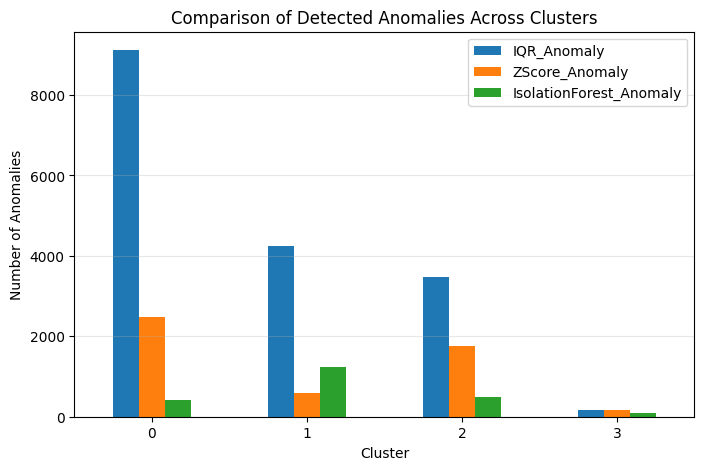

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
ax = cross_reference[
    [
        "IQR_Anomaly",
        "ZScore_Anomaly",
        "IsolationForest_Anomaly"
    ]
].plot(
    kind="bar",
    figsize=(8,5)
)

ax.set_title("Comparison of Detected Anomalies Across Clusters")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Anomalies")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

## Interpretation of Cross-reference Results

Berdasarkan hasil tabel dan grafik di atas, diperoleh beberapa temuan penting sebagai berikut.

- **Cluster 0** memiliki jumlah anggota terbesar sehingga menghasilkan jumlah anomali absolut yang paling tinggi. Namun, proporsi anomali relatif rendah sehingga cluster ini masih didominasi oleh pelanggan dengan karakteristik normal.
- **Cluster 1** dan **Cluster 2** menunjukkan proporsi anomali yang lebih tinggi dibandingkan Cluster 0. Hal ini menunjukkan bahwa kedua cluster memiliki karakteristik yang lebih berbeda dibandingkan populasi utama.
- **Cluster 3** memiliki jumlah anggota paling sedikit, tetapi hampir seluruh anggotanya terdeteksi sebagai anomali oleh metode IQR dan Z-Score serta sebagian besar juga terdeteksi oleh Isolation Forest. Kondisi ini menunjukkan bahwa Cluster 3 merupakan kelompok pelanggan yang paling berbeda dibandingkan cluster lainnya.

Perbedaan hasil antar metode juga menunjukkan bahwa setiap algoritma memiliki karakteristik deteksi yang berbeda. **IQR** lebih sensitif terhadap nilai ekstrem, **Z-Score** mendeteksi penyimpangan berdasarkan distribusi data, sedangkan **Isolation Forest** mampu mengidentifikasi anomali berdasarkan kombinasi beberapa atribut secara bersamaan.

Hasil cross-reference ini menunjukkan bahwa anomali tidak tersebar secara merata pada seluruh cluster, melainkan terkonsentrasi pada cluster tertentu. Oleh karena itu, cluster dengan proporsi anomali yang tinggi dipilih sebagai fokus investigasi pada tahap berikutnya.

In [ ]:
# ============================================================
# Top Flagged Anomalies for Investigation
# ============================================================

# Ambil hanya data yang dianggap anomaly oleh Isolation Forest
flagged = raw_data[raw_data["iso_label"] == -1].copy()

# Tambahkan anomaly score
flagged["anomaly_score"] = iso_scores[raw_data["iso_label"] == -1]

# Urutkan berdasarkan skor anomaly (semakin kecil semakin anomali)
flagged = flagged.sort_values("anomaly_score")

# Kolom penting untuk investigasi
columns_to_show = [
    "cluster",
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "anomaly_score"
]

display(flagged[columns_to_show].head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,cluster,age,balance,duration,campaign,pdays,previous,anomaly_score
45150,1,65,2352,354,3,188,13,-0.113361
43342,1,27,6791,174,2,229,28,-0.112278
43839,1,57,2986,1563,1,166,3,-0.105163
41375,1,43,7702,108,7,102,3,-0.103604
45002,1,36,2646,169,1,182,10,-0.101884
44349,1,45,4831,852,3,182,11,-0.100297
42413,2,43,11891,821,5,242,1,-0.098931
43619,1,64,2352,153,2,182,11,-0.098143
30180,1,58,-382,398,4,189,12,-0.093817
40590,2,42,11008,822,6,405,1,-0.093440


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Top Flagged Anomalies

Setelah seluruh data anomali berhasil diidentifikasi menggunakan **Isolation Forest**, langkah berikutnya adalah memilih beberapa observasi yang memiliki tingkat anomali paling tinggi untuk dilakukan investigasi lebih lanjut.

Pada tahap ini dipilih **10 data dengan nilai anomaly score terendah**, karena semakin kecil nilai anomaly score yang dihasilkan oleh Isolation Forest, semakin besar kemungkinan observasi tersebut memiliki karakteristik yang berbeda dibandingkan mayoritas data.

Tabel berikut menampilkan informasi penting dari setiap observasi, seperti **cluster**, **usia (age)**, **saldo rekening (balance)**, **durasi percakapan (duration)**, **jumlah kontak pada kampanye saat ini (campaign)**, **jumlah hari sejak kontak terakhir (pdays)**, **jumlah kontak pada kampanye sebelumnya (previous)**, serta **anomaly score**.

Data-data tersebut akan digunakan sebagai dasar untuk melakukan klasifikasi dan interpretasi bisnis pada tahap investigasi berikutnya.

In [ ]:
def classify_with_reason(row):

    # 1. Saldo negatif + kontak berulang
    if row["balance"] < 0 and row["previous"] >= 10:
        return (
            "Potential Risk Signal",
            "Nasabah memiliki saldo negatif tetapi telah dihubungi berkali-kali. Hal ini mengindikasikan adanya upaya pemasaran yang intensif terhadap pelanggan dengan potensi konversi yang rendah."
        )

    # 2. Saldo sangat tinggi
    if row["balance"] >= 10000:
        return (
            "Rare Legitimate Case",
            "Saldo rekening jauh lebih tinggi dibandingkan mayoritas pelanggan sehingga kemungkinan merupakan nasabah bernilai tinggi (high-value customer), bukan kesalahan data."
        )

    # 3. Previous contact tinggi
    if row["previous"] >= 10:
        return (
            "Potential Risk Signal",
            f"Nasabah telah dihubungi sebelumnya sebanyak {row['previous']} kali. Frekuensi kontak yang sangat tinggi menunjukkan pola pemasaran yang tidak biasa dan perlu dievaluasi efektivitasnya."
        )

    # 4. Campaign tinggi
    if row["campaign"] >= 6:
        return (
            "Potential Risk Signal",
            f"Nasabah telah dihubungi sebanyak {row['campaign']} kali pada kampanye saat ini. Intensitas kampanye yang tinggi dapat mengindikasikan strategi pemasaran yang kurang efektif."
        )

    # 5. Durasi sangat panjang
    if row["duration"] >= 1000:
        return (
            "Needs Further Investigation",
            "Durasi percakapan jauh lebih panjang dibandingkan mayoritas pelanggan. Kondisi ini menunjukkan perilaku pelanggan yang tidak umum sehingga perlu dianalisis lebih lanjut."
        )

    return (
        "Needs Further Investigation",
        "Karakteristik pelanggan berbeda dari mayoritas populasi, namun belum terdapat indikator yang cukup untuk menentukan penyebab utama anomali."
    )


# ============================================================
# Terapkan klasifikasi
# ============================================================

flagged_analysis = flagged.head(10).copy()

flagged_analysis[
    ["Classification", "Reason"]
] = flagged_analysis.apply(
    lambda row: pd.Series(classify_with_reason(row)),
    axis=1
)

# ============================================================
# Tampilkan hasil
# ============================================================

display(
    flagged_analysis[
        [
            "cluster",
            "age",
            "balance",
            "duration",
            "campaign",
            "pdays",
            "previous",
            "Classification",
            "Reason"
        ]
    ]
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,cluster,age,balance,duration,campaign,pdays,previous,Classification,Reason
45150,1,65,2352,354,3,188,13,Potential Risk Signal,Nasabah telah dihubungi sebelumnya sebanyak 13...
43342,1,27,6791,174,2,229,28,Potential Risk Signal,Nasabah telah dihubungi sebelumnya sebanyak 28...
43839,1,57,2986,1563,1,166,3,Needs Further Investigation,Durasi percakapan jauh lebih panjang dibanding...
41375,1,43,7702,108,7,102,3,Potential Risk Signal,Nasabah telah dihubungi sebanyak 7 kali pada k...
45002,1,36,2646,169,1,182,10,Potential Risk Signal,Nasabah telah dihubungi sebelumnya sebanyak 10...
44349,1,45,4831,852,3,182,11,Potential Risk Signal,Nasabah telah dihubungi sebelumnya sebanyak 11...
42413,2,43,11891,821,5,242,1,Rare Legitimate Case,Saldo rekening jauh lebih tinggi dibandingkan ...
43619,1,64,2352,153,2,182,11,Potential Risk Signal,Nasabah telah dihubungi sebelumnya sebanyak 11...
30180,1,58,-382,398,4,189,12,Potential Risk Signal,Nasabah memiliki saldo negatif tetapi telah di...
40590,2,42,11008,822,6,405,1,Rare Legitimate Case,Saldo rekening jauh lebih tinggi dibandingkan ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Classification of Flagged Anomalies

Setelah seluruh metode deteksi anomali diterapkan, dilakukan investigasi terhadap **10 data dengan nilai anomaly score terendah** yang dihasilkan oleh Isolation Forest. Data tersebut dipilih karena memiliki karakteristik yang paling berbeda dibandingkan mayoritas pelanggan.

Untuk mempermudah analisis, setiap data diklasifikasikan ke dalam beberapa kategori berikut:

- **Rare Legitimate Case** → Data valid yang memiliki karakteristik sangat jarang ditemukan, misalnya pelanggan dengan saldo yang jauh lebih tinggi dibandingkan mayoritas pelanggan.
- **Potential Risk Signal** → Data yang menunjukkan pola pemasaran atau perilaku pelanggan yang tidak biasa sehingga perlu menjadi perhatian pihak bisnis.
- **Needs Further Investigation** → Data yang memiliki karakteristik berbeda namun belum terdapat bukti yang cukup untuk menentukan penyebab utama anomali sehingga memerlukan analisis lanjutan.

Hasil klasifikasi ditampilkan pada tabel berikut.

# Business Interpretation of Flagged Anomalies

Berdasarkan hasil investigasi terhadap 10 data dengan nilai anomaly score terendah, diperoleh beberapa temuan penting sebagai berikut.

### 1. Rare Legitimate Case

Beberapa data anomali memiliki saldo rekening yang jauh lebih tinggi dibandingkan mayoritas pelanggan. Karakteristik tersebut menunjukkan bahwa pelanggan kemungkinan merupakan **nasabah bernilai tinggi (high-value customer)**. Oleh karena itu, data tersebut tidak dapat dianggap sebagai kesalahan pencatatan, melainkan merupakan kasus yang valid namun jarang ditemukan.

### 2. Potential Risk Signal

Sebagian besar data anomali menunjukkan jumlah **previous contact** maupun **campaign** yang jauh lebih tinggi dibandingkan pelanggan normal. Kondisi ini mengindikasikan bahwa pelanggan telah dihubungi berulang kali namun belum menunjukkan respons yang sesuai dengan mayoritas pelanggan. Hal tersebut dapat menjadi indikasi bahwa strategi pemasaran yang diterapkan kurang efektif dan perlu dievaluasi.

Selain itu, ditemukan pelanggan dengan saldo negatif yang tetap menjadi target pemasaran secara berulang. Kondisi ini menunjukkan adanya kemungkinan alokasi sumber daya pemasaran yang kurang optimal sehingga memerlukan perhatian lebih lanjut.

### 3. Needs Further Investigation

Beberapa pelanggan memiliki durasi percakapan yang jauh lebih panjang dibandingkan mayoritas pelanggan. Kondisi ini belum dapat secara langsung dikategorikan sebagai risiko bisnis maupun kesalahan data sehingga memerlukan investigasi lebih lanjut untuk memahami penyebabnya.

### Overall Interpretation

Secara keseluruhan, hasil investigasi menunjukkan bahwa sebagian besar anomali **bukan disebabkan oleh kesalahan data (data error)**, melainkan oleh karakteristik pelanggan yang memang berbeda secara signifikan dari populasi utama. Oleh karena itu, data anomali tidak sebaiknya langsung dihapus, melainkan dimanfaatkan sebagai sumber informasi untuk meningkatkan strategi segmentasi pelanggan, evaluasi efektivitas kampanye pemasaran, serta pengambilan keputusan bisnis di masa mendatang.

# Overall Findings

Berdasarkan hasil deteksi dan investigasi anomali pada dataset Bank Marketing, diperoleh beberapa temuan utama sebagai berikut.

### 1. Perbandingan Metode Deteksi Anomali

Ketiga metode yang digunakan, yaitu **Interquartile Range (IQR)**, **Z-Score**, dan **Isolation Forest**, menunjukkan karakteristik deteksi yang berbeda.

- **IQR** mendeteksi jumlah outlier paling banyak karena lebih sensitif terhadap nilai ekstrem pada setiap atribut numerik.
- **Z-Score** menghasilkan jumlah outlier yang lebih sedikit karena mempertimbangkan distribusi data berdasarkan rata-rata dan standar deviasi.
- **Isolation Forest** mendeteksi anomali berdasarkan pola multidimensi sehingga mampu mengidentifikasi observasi yang benar-benar berbeda dari mayoritas pelanggan.

Perbedaan tersebut menunjukkan bahwa penggunaan beberapa metode secara bersamaan memberikan hasil deteksi yang lebih komprehensif dibandingkan hanya menggunakan satu metode.

### 2. Hasil Cross-reference dengan Clustering

Hasil cross-reference menunjukkan bahwa distribusi anomali tidak tersebar secara merata pada seluruh cluster.

Cluster 1, Cluster 2, dan terutama Cluster 3 memiliki proporsi anomali yang jauh lebih tinggi dibandingkan Cluster 0. Hal ini menunjukkan bahwa hasil clustering pada Phase 2 berhasil mengelompokkan pelanggan dengan karakteristik yang berbeda dari populasi utama sehingga layak dilakukan investigasi lebih lanjut.

### 3. Karakteristik Anomali

Hasil investigasi terhadap data dengan nilai anomaly score terendah menunjukkan bahwa sebagian besar anomali memiliki salah satu karakteristik berikut:

- Saldo rekening yang jauh lebih tinggi dibandingkan mayoritas pelanggan.
- Frekuensi kontak pemasaran (**campaign** maupun **previous contact**) yang sangat tinggi.
- Durasi percakapan yang jauh lebih panjang dibandingkan pelanggan pada umumnya.

Karakteristik tersebut menunjukkan bahwa anomali tidak hanya berasal dari nilai ekstrem pada satu atribut, tetapi juga dari kombinasi beberapa atribut yang membentuk pola pelanggan yang berbeda.

### 4. Business Insight

Sebagian besar anomali dikategorikan sebagai **Potential Risk Signal** dan **Rare Legitimate Case**, sedangkan tidak ditemukan indikasi kuat adanya **Data Error** pada data yang diinvestigasi.

Temuan ini menunjukkan bahwa mayoritas anomali merupakan karakteristik pelanggan yang memang berbeda secara signifikan dari populasi utama, bukan disebabkan oleh kesalahan pencatatan data.

### 5. Kesimpulan

Secara keseluruhan, penggunaan kombinasi metode statistik dan machine learning berhasil mengidentifikasi pola pelanggan yang tidak umum pada dataset Bank Marketing.

Informasi tersebut dapat dimanfaatkan oleh pihak bank untuk:

- Mengevaluasi efektivitas strategi telemarketing terhadap pelanggan yang telah dihubungi berulang kali.
- Mengidentifikasi pelanggan bernilai tinggi (high-value customer) yang memerlukan pendekatan pemasaran yang lebih personal.
- Mendukung proses segmentasi pelanggan dan pengambilan keputusan bisnis berdasarkan karakteristik pelanggan yang berbeda dari mayoritas populasi.

# Kesimpulan Phase 4

Phase 4 berhasil mengidentifikasi anomali menggunakan tiga pendekatan berbeda, yaitu IQR, Z-Score, dan Isolation Forest. Hasil perbandingan menunjukkan bahwa setiap metode memiliki karakteristik deteksi yang berbeda sehingga saling melengkapi dalam proses identifikasi outlier.

Melalui cross-reference dengan hasil clustering pada Phase 2, diketahui bahwa distribusi anomali terkonsentrasi pada cluster tertentu yang memang memiliki karakteristik berbeda dibandingkan populasi utama. Investigasi terhadap data dengan anomaly score terendah menunjukkan bahwa sebagian besar anomali merupakan **Potential Risk Signal** dan **Rare Legitimate Case**, sedangkan tidak ditemukan indikasi kuat adanya **Data Error**.

Secara keseluruhan, hasil Phase 4 memberikan informasi yang dapat dimanfaatkan untuk mendukung evaluasi strategi telemarketing, identifikasi pelanggan bernilai tinggi, serta penyusunan strategi segmentasi pelanggan yang lebih efektif.

In [ ]:
# ============================================================
# EXPORT CSV UNTUK DASHBOARD (v2) — jalankan di akhir notebook,
# setelah cell 140 (butuh: raw_data, iso_labels, iso_scores,
# rules_sorted, display_clean_rules, classify_with_reason)
# ============================================================

# 1. cluster_result.csv — pie chart & scatter segmentasi
cluster_result = raw_data[[
    "age", "balance", "duration", "campaign", "pdays", "previous",
    "job", "marital", "education", "housing", "loan", "y", "cluster"
]].copy()
cluster_result.to_csv("cluster_result.csv", index=False)

# 2. outlier_result.csv — sekarang termasuk duration/campaign/pdays/previous
#    supaya scatter plot bisa pakai sumbu selain age/balance (sesuai temuan
#    Phase 4 bahwa outlier lebih kentara di kolom-kolom ini)
outlier_result = raw_data[[
    "age", "balance", "duration", "campaign", "pdays", "previous", "cluster"
]].copy()
outlier_result["anomaly_score"] = iso_scores
outlier_result["Outlier"] = np.where(iso_labels == -1, "Outlier", "Normal")
outlier_result.to_csv("outlier_result.csv", index=False)

# 3. outlier_classification.csv — BARU: 10 anomali teratas + alasan bisnis
#    (pakai ulang classify_with_reason yang sudah didefinisikan di cell 139)
flagged = raw_data[raw_data["iso_label"] == -1].copy() if "iso_label" in raw_data.columns \
    else raw_data.loc[iso_labels == -1].copy()
flagged["anomaly_score"] = iso_scores[iso_labels == -1]
flagged = flagged.sort_values("anomaly_score").head(10).reset_index(drop=True)

flagged[["Classification", "Reason"]] = flagged.apply(
    lambda row: pd.Series(classify_with_reason(row)), axis=1
)

outlier_classification = flagged[[
    "cluster", "age", "balance", "duration", "campaign", "pdays", "previous",
    "anomaly_score", "Classification", "Reason"
]].round({"anomaly_score": 4})
outlier_classification.to_csv("outlier_classification.csv", index=False)

# 4. cluster_summary.csv — profil tiap cluster dalam skala ASLI
cluster_summary = raw_data.groupby("cluster").agg(
    size=("cluster", "count"),
    avg_age=("age", "mean"),
    avg_balance=("balance", "mean"),
    avg_duration=("duration", "mean"),
    avg_campaign=("campaign", "mean"),
    avg_pdays=("pdays", "mean"),
    avg_previous=("previous", "mean"),
    pct_housing=("housing", lambda x: (x == "yes").mean() * 100),
    pct_subscribed=("y", lambda x: (x == "yes").mean() * 100),
).round(2).reset_index()
cluster_summary["pct_of_total"] = (cluster_summary["size"] / len(raw_data) * 100).round(2)
cluster_summary.to_csv("cluster_summary.csv", index=False)

# 5. association_rules.csv — gabungan top 10 positive + top 10 negative
pos_rules = display_clean_rules(rules_sorted, target="y_yes", top_n=10)
neg_rules = display_clean_rules(rules_sorted, target="y_no", top_n=10)
association_rules_export = pd.concat([pos_rules, neg_rules], ignore_index=True)
association_rules_export.columns = [
    "rank", "pattern", "prediction", "support", "confidence", "lift"
]
association_rules_export.to_csv("association_rules.csv", index=False)

# 6. dashboard_kpi.csv — satu baris ringkasan untuk KPI cards
dashboard_kpi = pd.DataFrame([{
    "total_customers": len(raw_data),
    "n_clusters": raw_data["cluster"].nunique(),
    "top_rules_shown": len(association_rules_export),
    "total_outliers": int((iso_labels == -1).sum()),
}])
dashboard_kpi.to_csv("dashboard_kpi.csv", index=False)

print("6 file CSV berhasil dibuat:")
for f in ["cluster_result.csv", "outlier_result.csv", "outlier_classification.csv",
          "cluster_summary.csv", "association_rules.csv", "dashboard_kpi.csv"]:
    print(" -", f)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

6 file CSV berhasil dibuat:
 - cluster_result.csv
 - outlier_result.csv
 - outlier_classification.csv
 - cluster_summary.csv
 - association_rules.csv
 - dashboard_kpi.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag